<a href="https://colab.research.google.com/github/yuri-spizhovyi-mit/ET6-ML/blob/main/Session1__data_analysis/notebooks/predicting_life_expectancy_in_the_us.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌎 Life Expectancy in the US – MIT UAI Course

**Author:** Yuri Spizhovyi  
**Source:** [Effective Data Visualization – UAI Course](https://courses.mitxonline.mit.edu/)  
**Dataset:** `statedata.csv` (from R dataset repository)  
**Repo:** [My Repo](https://github.com/yuri-spizhovyi-mit/ET6-ML)

---

This notebook provides a step-by-step solution to the *Life Expectancy* assignment from the MIT UAI Course.  
It includes data loading, exploration, visualization, and initial insights using Python (Pandas, Matplotlib, and Seaborn) in Google Colab.

> 📌 **Goal**: Understand how different factors like income, illiteracy, murder rate, education, and geography relate to life expectancy in US states.

---


## Step 1: Clone the repo and import libraries
Begin by cloning the repo and navigate to the dataset


In [9]:
# Remove previously cloned or duplicated folders (optional, safe cleanup)
!rm -rf ET6-ML ET6-ML_*

In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

# Clone once per session
!git clone https://github.com/yuri-spizhovyi-mit/ET6-ML.git

# Move into the correct folder
%cd ET6-ML

Cloning into 'ET6-ML'...
remote: Enumerating objects: 194, done.
remote: Counting objects: 100% (95/95), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 194 (delta 55), reused 52 (delta 30), pack-reused 99 (from 1)
Receiving objects: 100% (194/194), 7.53 MiB | 10.41 MiB/s, done.
Resolving deltas: 100% (94/94), done.
/content/ET6-ML/ET6-ML/ET6-ML/ET6-ML/ET6-ML/ET6-ML/ET6-ML


## Step 2: Load the Data

Start by loading the `statedata.csv` file using Pandas and previewing the first few rows.


In [77]:
df_state = pd.read_csv("Session1__data_analysis/data/statedata.csv")
df_state.head()

,Population,Income,Illiteracy,Life.Exp,Murder,HS.Grad,Frost,Area,state.abb,state.area,x,y,state.division,state.name,state.region
0,3615,3624,2.1,69.05,15.1,41.3,20,50708,AL,51609,-86.7509,32.5901,East South Central,Alabama,South
1,365,6315,1.5,69.31,11.3,66.7,152,566432,AK,589757,-127.2500,49.2500,Pacific,Alaska,West
2,2212,4530,1.8,70.55,7.8,58.1,15,113417,AZ,113909,-111.6250,34.2192,Mountain,Arizona,West
3,2110,3378,1.9,70.66,10.1,39.9,65,51945,AR,53104,-92.2992,34.7336,West South Central,Arkansas,South
4,21198,5114,1.1,71.71,10.3,62.6,20,156361,CA,158693,-119.7730,36.5341,Pacific,California,West


## Step 3.1: Data Cleaning

### 3.1.1 Identify Missing Data

Before any transformation, inspect the dataset for missing (null) values.  
Missing values can affect calculations, aggregations, and model performance.

Use `isnull().sum()` to count missing values for each column.



In [78]:
df_state.isnull().sum()

,0
Population,0
Income,0
Illiteracy,0
Life.Exp,0
Murder,0
HS.Grad,0
Frost,0
Area,0
state.abb,0
state.area,0


## Step 3.2. Explore the Cleaned Data
3.2.1 View summary statistics for the numeric fields in the dataset.

In [79]:
df_describe = df_state.describe()
df_describe

,Population,Income,Illiteracy,Life.Exp,Murder,HS.Grad,Frost,Area,state.area,x,y
count,50.000000,50.000000,50.000000,50.000000,50.00000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,4246.420000,4435.800000,1.170000,70.878600,7.37800,53.108000,104.460000,70735.880000,72367.980000,-92.464138,39.410740
std,4464.491433,614.469939,0.609533,1.342394,3.69154,8.076998,51.980848,85327.299622,88278.006201,16.180787,4.976349
min,365.000000,3098.000000,0.500000,67.960000,1.40000,37.800000,0.000000,1049.000000,1214.000000,-127.250000,27.874400
25%,1079.500000,3992.750000,0.625000,70.117500,4.35000,48.050000,66.250000,36985.250000,37317.000000,-104.159500,35.548150
50%,2838.500000,4519.000000,0.950000,70.675000,6.85000,53.250000,114.500000,54277.000000,56222.000000,-89.900300,39.620750
75%,4968.500000,4813.500000,1.575000,71.892500,10.67500,59.150000,139.750000,81162.500000,83233.750000,-78.977850,43.136100
max,21198.000000,6315.000000,2.800000,73.600000,15.10000,67.300000,188.000000,566432.000000,589757.000000,-68.980100,49.250000


In [80]:
df_coordinates = df_state[['x', 'y']]
df_coordinates[:5]


,x,y
0,-86.7509,32.5901
1,-127.2500,49.2500
2,-111.6250,34.2192
3,-92.2992,34.7336
4,-119.7730,36.5341


## Problem 1.1 - Data Exploration
We begin by exploring the data. Plot all of the states' centers with latitude on the y-axis (the "y" variable in our dataset) and longitude on the x-axis (the "x" variable in our dataset) using the Matplotlib library's scatter command. The shape of the plot should look like the outline of the United States! Note that Alaska and Hawaii have had their coordinates adjusted to appear just off of the West Coast.

In the Python command you used to generate this plot, which variable name did you use as the first argument?

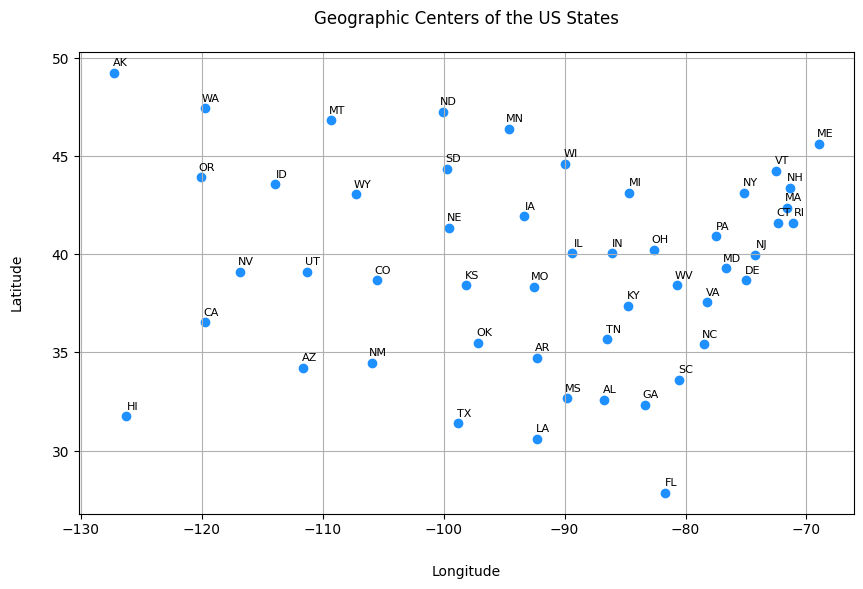

In [81]:
# Create the scatter plot as describe above
plt.figure(figsize=(10,6))
plt.scatter(df_state['x'], df_state['y'], color='dodgerblue')

# Annotate each point with the state name
for i in range(len(df_state)):
  plt.text(df_state['x'][i]+0.5, df_state['y'][i]+0.5, df_state['state.abb'][i], fontsize=8, ha='center', va='center')

# Add labels and title
plt.xlabel('Longitude', labelpad=20)
plt.ylabel('Latitude', labelpad=20)
plt.title('Geographic Centers of the US States', pad=20)
plt.grid(True)


## Problem 1.2 - Data Exploration
1 point possible (graded)
Now, make a boxplot of the murder rate by region.

Which region has the highest median murder rate?

In [92]:
df_murder = df_state.groupby('state.region')['Murder'].median()
df_murder

,Murder
state.region,
North Central,3.75
Northeast,3.30
South,10.85
West,6.80


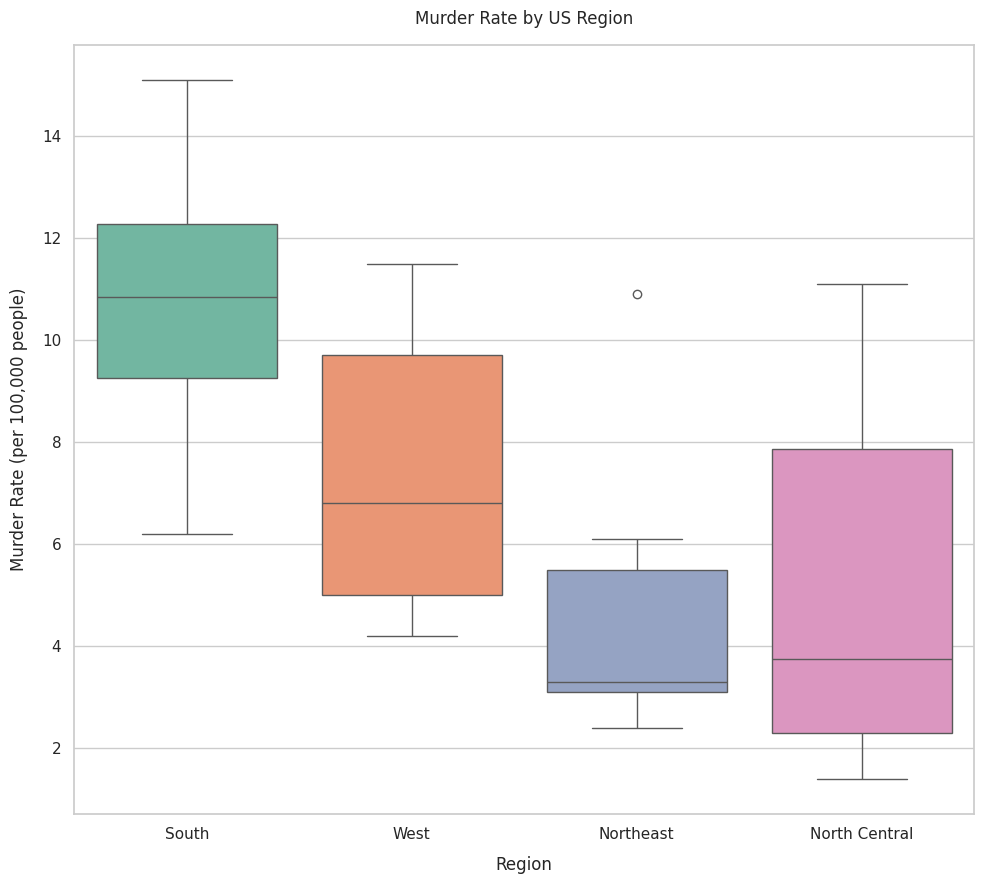

In [98]:
# Create a boxplot

# Set plot style
sns.set(style='whitegrid')

# Create the boxplot
plt.figure(figsize=(10, 9))
sns.boxplot(df_state, x = 'state.region', y='Murder', palette='Set2')

# Add title and labels
plt.title("Murder Rate by US Region", pad=15)
plt.xlabel("Region", labelpad=10)
plt.ylabel('Murder Rate (per 100,000 people)', labelpad=10)

# Show the plot
plt.tight_layout()

## Problem 1.3 - Data Exploration
0.0/1.0 point (graded)
You should see that there is an outlier in the Northeast region of the boxplot you just generated. Which state does this correspond to? (Hint: There are many ways to find the answer to this question, but one way is to use the subset command to only look at the Northeast data.)

In [117]:
df_northeast = df_state[df_state['state.region'] == "Northeast"]
df_northeast[['Murder', 'state.name']].sort_values(by='Murder', ascending=False)

,Murder,state.name
31,10.9,New York
37,6.1,Pennsylvania
44,5.5,Vermont
29,5.2,New Jersey
20,3.3,Massachusetts
28,3.3,New Hampshire
6,3.1,Connecticut
18,2.7,Maine
38,2.4,Rhode Island


## Problem 2.1 - Predicting Life Expectancy - An Initial Model
1 point possible (graded)
We would like to build a model to predict life expectancy by state using the state statistics we have in our dataset.

Build the model with all potential variables included (Population, Income, Illiteracy, Murder, HS.Grad, Frost, and Area). Note that you should use the variable "Area" in your model, NOT the variable "state.area".

What is the coefficient for "Income" in your linear regression model? Use the model.coef_ command.

In [129]:
# Define the features and target
features = ["Population", "Income", "Illiteracy", "Murder", "HS.Grad", "Frost", "Area"]
X = df_state[features]
y = df_state['Life.Exp']

# Fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Collect and sort coefficients:
coef_pairs = list(zip(features, model.coef_))
coef_pairs_sorted_abs = sorted(coef_pairs, key=lambda x: abs(x[1])) # sort by |coef|

# Display all coefficients
for name, coef in coef_pairs_sorted_abs:
  print(f"{name}: {coef:.6f}")

Area: -0.000000
Income: -0.000022
Population: 0.000052
Frost: -0.005735
Illiteracy: 0.033820
HS.Grad: 0.048929
Murder: -0.301123


## Problem 2.2 - Predicting Life Expectancy - An Initial Model
1/1 point (graded)
Call the coefficient for income x (the answer to Problem 2.1). What is the interpretation of the coefficient x?

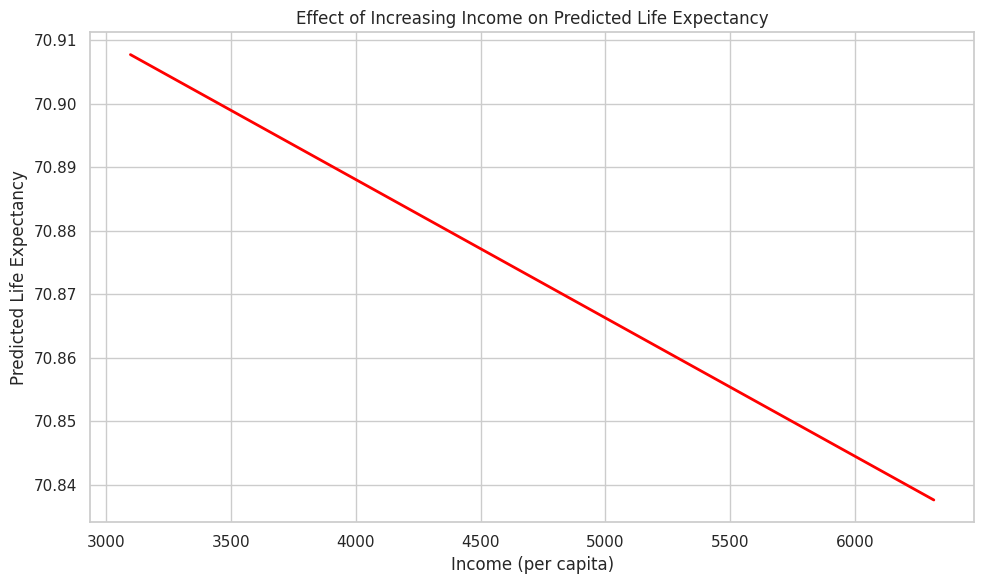

In [123]:
# Fix all features at their mean value
means = X.mean()

# Generate a range of income values around the actual range
income_range = np.linspace(X["Income"].min(), X["Income"].max(), 100)

# Prepare the prediction DataFrame
X_test = pd.DataFrame({
    "Population": means["Population"],
    "Income": income_range,
    "Illiteracy": means["Illiteracy"],
    "Murder": means["Murder"],
    "HS.Grad": means["HS.Grad"],
    "Frost": means["Frost"],
    "Area": means["Area"],
})

# Predict life expectancy for each income value
predicted_life_exp = model.predict(X_test)

# Plot the result
plt.figure(figsize=(10, 6))
plt.plot(income_range, predicted_life_exp, color="red", linewidth=2)
plt.xlabel("Income (per capita)")
plt.ylabel("Predicted Life Expectancy")
plt.title("Effect of Increasing Income on Predicted Life Expectancy")
plt.grid(True)
plt.tight_layout()
plt.show()

## Problem 2.3 - Predicting Life Expectancy - An Initial Model
1 point possible (graded)
Now plot a graph of life expectancy vs. income.

Visually observe the plot. What appears to be the relationship?

Text(0, 0.5, 'Life Expectancy')

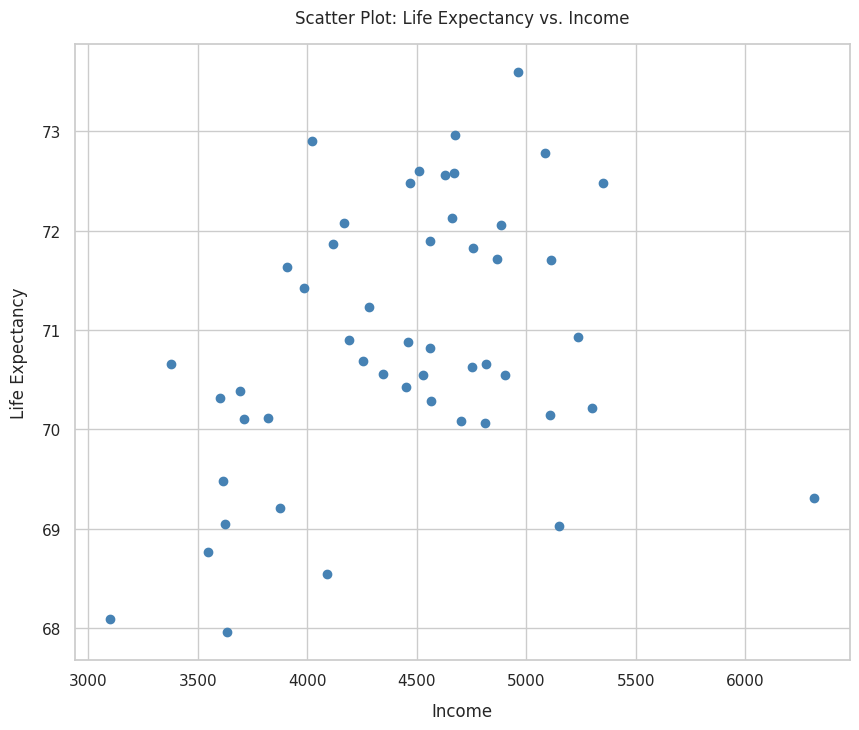

In [126]:
# Plot a graph of life expectancy vs. income

plt.figure(figsize=(10, 8))
plt.scatter(df_state['Income'], df_state['Life.Exp'], color='steelblue')
plt.title("Scatter Plot: Life Expectancy vs. Income", pad=15)
plt.xlabel("Income", labelpad=10)
plt.ylabel("Life Expectancy", labelpad=10)

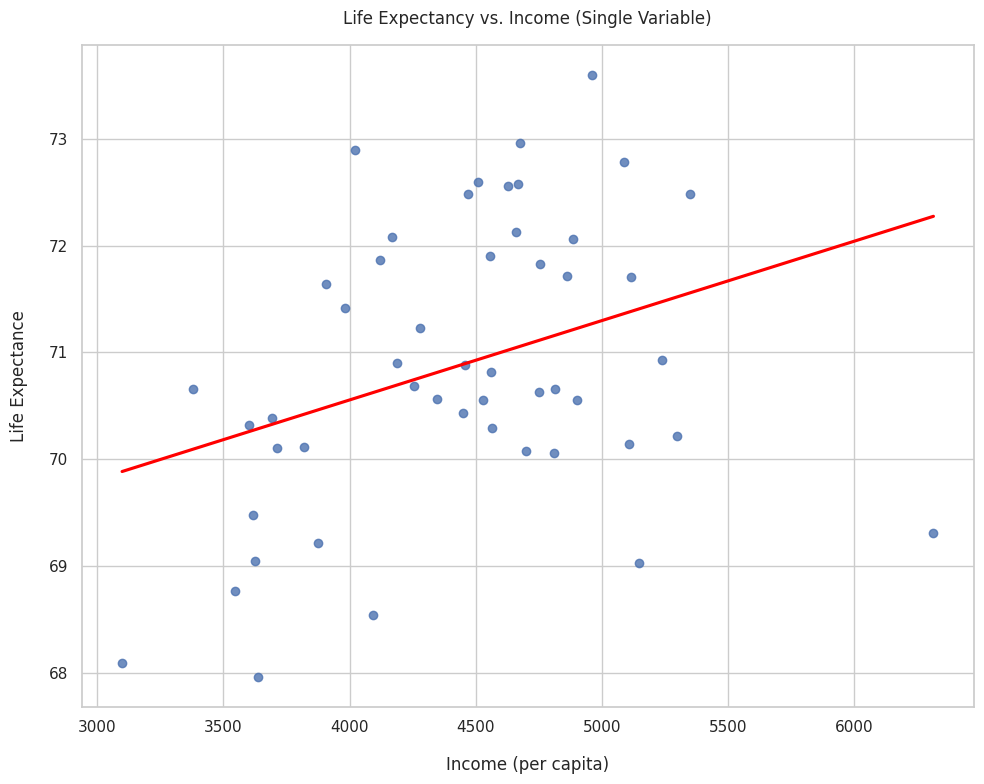

In [128]:
# Plot "life expectancy vs. income" regression graph

# Set visual style
sns.set(style="whitegrid")

# Create scatter plot with regression line
plt.figure(figsize=(10, 8))
sns.regplot(data=df_state, x='Income', y='Life.Exp', ci=None, line_kws={'color':'red'})

# Labe and title
plt.xlabel("Income (per capita)", labelpad=15)
plt.ylabel("Life Expectance", labelpad=15)
plt.title("Life Expectancy vs. Income (Single Variable)", pad=15)

plt.tight_layout()

## Problem 3.1 - Predicting Life Expectancy - Refining the Model and Analyzing Predictions
1 point possible (graded)
Recall that we discussed the principle of simplicity: that is, a model with fewer variables is preferable to a model with many unnnecessary variables. Experiment with removing independent variables from the original model. Remember to use the significance of the coefficients to decide which variables to remove (remove the one with the largest "p-value" first, or the one with the "t value" closest to zero), and to remove them one at a time (this is called "backwards variable selection"). This is important due to multicollinearity issues - removing one insignificant variable may make another previously insignificant variable become significant.

You should be able to find a good model with only 4 independent variables, instead of the original 7. Which variables does this model contain?

In [131]:
# Step 1: Add constant for intercept
X = sm.add_constant(df_state[features])
y = df_state["Life.Exp"]

# Step 2: Fit the full model
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:               Life.Exp   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.692
Method:                 Least Squares   F-statistic:                     16.74
Date:                Sun, 06 Jul 2025   Prob (F-statistic):           2.53e-10
Time:                        20:01:04   Log-Likelihood:                -51.855
No. Observations:                  50   AIC:                             119.7
Df Residuals:                      42   BIC:                             135.0
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         70.9432      1.748     40.586      0.0

# Remove Area (remove the one with the largest "p-value" first, or the one with the "t value" closest to zero)
Area t = -0.044 - closest to 0
Area P = 0.965 - largest p-value

In [136]:
features = ["Population", "Income", "Illiteracy", "Murder", "HS.Grad", "Frost"]  # Area removed
X = sm.add_constant(df_state[features])
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               Life.Exp   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.699
Method:                 Least Squares   F-statistic:                     19.99
Date:                Sun, 06 Jul 2025   Prob (F-statistic):           5.36e-11
Time:                        20:10:59   Log-Likelihood:                -51.856
No. Observations:                  50   AIC:                             117.7
Df Residuals:                      43   BIC:                             131.1
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         70.9893      1.387     51.165      0.0

# Remove Illiteracy (remove the one with the largest "p-value" first, or the one with the "t value" closest to zero)
Illiteracy t = 0.083  - closest to 0
Illiteracy P = 0.934 - largest p-value

In [135]:
features = ["Population", "Income", "Murder", "HS.Grad", "Frost"]  # Illiteracy removed
X = sm.add_constant(df_state[features])
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               Life.Exp   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.706
Method:                 Least Squares   F-statistic:                     24.55
Date:                Sun, 06 Jul 2025   Prob (F-statistic):           1.02e-11
Time:                        20:10:39   Log-Likelihood:                -51.860
No. Observations:                  50   AIC:                             115.7
Df Residuals:                      44   BIC:                             127.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         71.0658      1.029     69.067      0.0

# Remove Income (remove the one with the largest "p-value" first, or the one with the "t value" closest to zero)
Income t = -0.107  - closest to 0
Income P = 0.915 - largest p-value

In [138]:
features = ["Population", "Murder", "HS.Grad", "Frost"]  # Income removed
X = sm.add_constant(df_state[features])
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               Life.Exp   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.713
Method:                 Least Squares   F-statistic:                     31.37
Date:                Sun, 06 Jul 2025   Prob (F-statistic):           1.70e-12
Time:                        20:36:47   Log-Likelihood:                -51.866
No. Observations:                  50   AIC:                             113.7
Df Residuals:                      45   BIC:                             123.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         71.0271      0.953     74.542      0.0

## Conclusion

Three variables — **Murder**, **HS.Grad**, and **Frost** — have p-values less than 0.05, indicating they are statistically significant predictors of life expectancy. The variable **Population** has a p-value slightly above 0.05 (≈ 0.052), making it marginally non-significant; however, due to its borderline value and contribution to the overall model, it may still be considered for inclusion in a good predictive model.

## Problem 3.3 - Predicting Life Expectancy - Refining the Model and Analyzing Predictions
2 points possible (graded)
Using the simplified 4 variable model that we created, we'll now take a look at how our predictions compare to the actual values.

Take a look at the vector of predictions by using the predict function.

Which state do we predict to have the lowest life expectancy?

In [145]:
# Get prediction
prediction = model.predict(X)

# Add prediction to DataFrame
df_state['Predicted_Life.Exp'] = prediction

# Sort by predicted life expectance
lowest_predicted = df_state.sort_values(by="Predicted_Life.Exp").head(1)
lowest_actual = df_state.sort_values(by="Life.Exp").head(1)

# Show result
print("📉 Lowest predicted life expectancy:")
print(lowest_predicted[["state.name", "Predicted_Life.Exp"]])

print("\n📉 Lowest actual life expectancy:")
print(lowest_actual[["state.name", "Life.Exp"]])

📉 Lowest predicted life expectancy:
  state.name  Predicted_Life.Exp
0    Alabama           68.481119

📉 Lowest actual life expectancy:
        state.name  Life.Exp
39  South Carolina     67.96


## Problem 3.4 - Predicting Life Expectancy - Refining the Model and Analyzing Predictions
2 points possible (graded)
Which state do we predict to have the highest life expectancy?

In [150]:
# Sort by predicted life expectancy descending order
highest_predicted = df_state.sort_values(by="Predicted_Life.Exp", ascending=False).head(5)
highest_actual = df_state.sort_values(by="Life.Exp", ascending=False).head(5)


# Show result
print("📉 Highest predicted life expectancy:")
print(highest_predicted[["state.name", "Predicted_Life.Exp"]])

print("\n📉 Hieghest actual life expectancy:")
print(highest_actual[["state.name", "Life.Exp"]])

📉 Highest predicted life expectancy:
       state.name  Predicted_Life.Exp
46     Washington           72.682724
20  Massachusetts           72.441054
36         Oregon           72.414453
14           Iowa           72.396529
22      Minnesota           72.265596

📉 Hieghest actual life expectancy:
      state.name  Life.Exp
10        Hawaii     73.60
22     Minnesota     72.96
43          Utah     72.90
33  North Dakota     72.78
26      Nebraska     72.60


In [168]:
for i in range(len(df_state)):
    df_state['life.exp_residuals'] = abs(df_state['Predicted_Life.Exp'] - df_state['Life.Exp'])

le_residuals = df_state[['life.exp_residuals', 'state.name']]
le_residuals_sorted = le_residuals.sort_values(by='life.exp_residuals')
le_residuals_sorted
print(f"The smallest absolute error is {le_residuals_sorted.head(1)}")
print(f"The largest absolute error is {le_residuals_sorted.tail(1)}")



The smallest absolute error is     life.exp_residuals state.name
13            0.021585    Indiana
The largest absolute error is     life.exp_residuals state.name
10            1.506831     Hawaii
